In [ ]:
# Section A. Model Training
# =============================================================================

import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------------------
# A.1 Load the curated dataset (produced by 01_ingest_clean.ipynb)
# ----------------------------------------------------------------------------
print("Loading curated dataset...")
df = pd.read_parquet("../data/curated/home_credit_curated.parquet")

print(f"Dataset shape: {df.shape}")
print(f"TARGET distribution:\n{df['TARGET'].value_counts(normalize=True).round(4)}")
print(f"Columns: {list(df.columns)}")

# ----------------------------------------------------------------------------
# Separate features and target
# ----------------------------------------------------------------------------
X = df.drop(columns=["TARGET"])
y = df["TARGET"]

# ----------------------------------------------------------------------------
# A.1 Train-test split (80/20, stratified by TARGET)
# ----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train set shape: {X_train.shape} | Test set shape: {X_test.shape}")
print(f"Train TARGET ratio: {y_train.mean():.4f} | Test TARGET ratio: {y_test.mean():.4f}")

Loading curated dataset...
Dataset shape: (250655, 176)
TARGET distribution:
TARGET
0    0.9132
1    0.0868
Name: proportion, dtype: float64
Columns: ['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG

In [2]:
# ----------------------------------------------------------------------------
# A.2 Address class imbalance
# ----------------------------------------------------------------------------
# XGBoost: use scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"XGBoost scale_pos_weight (neg/pos) = {scale_pos_weight:.2f}")

# Logistic Regression: will use class_weight='balanced' + feature scaling

XGBoost scale_pos_weight (neg/pos) = 10.52


In [3]:
# ----------------------------------------------------------------------------
# A.3 Train at least two models
#    • Gradient boosted trees → XGBoost (required)
#    • Second model → Logistic Regression (with scaling)
# ----------------------------------------------------------------------------

print("\n=== Training XGBoost ===")
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=4000,          # more trees
    max_depth=4,               # shallower = less overfit
    learning_rate=0.05,        # lower LR with more trees
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,        # helps with imbalance
    reg_alpha=0.1,             # L1 regularisation
    reg_lambda=1.0,            # L2 regularisation
    eval_metric="auc",
    early_stopping_rounds=50,  # stop when val AUC plateaus
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)
print("XGBoost training completed.")

print("\n=== Training Logistic Regression ===")
# Scale features (LR is sensitive to scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
)
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression training completed.")


=== Training XGBoost ===
[0]	validation_0-auc:0.67137
[50]	validation_0-auc:0.73797
[100]	validation_0-auc:0.74822
[150]	validation_0-auc:0.75195
[200]	validation_0-auc:0.75391
[250]	validation_0-auc:0.75557
[300]	validation_0-auc:0.75716
[350]	validation_0-auc:0.75829
[400]	validation_0-auc:0.75869
[450]	validation_0-auc:0.75921
[500]	validation_0-auc:0.75970
[550]	validation_0-auc:0.76035
[600]	validation_0-auc:0.76049
[650]	validation_0-auc:0.76070
[698]	validation_0-auc:0.76059
XGBoost training completed.

=== Training Logistic Regression ===
Logistic Regression training completed.


In [4]:
# ----------------------------------------------------------------------------
# A.4 Compute metrics on the test set for every model
#    Metrics required: ROC-AUC, MCC, precision, recall, F1-score
# ----------------------------------------------------------------------------

def get_metrics(model, X, y_true, model_name, is_scaled=False):
    if is_scaled:
        y_pred_proba = model.predict_proba(X)[:, 1]
        y_pred = model.predict(X)
    else:
        y_pred_proba = model.predict_proba(X)[:, 1]
        y_pred = model.predict(X)

    return {
        "Model": model_name,
        "ROC-AUC": round(roc_auc_score(y_true, y_pred_proba), 4),
        "MCC": round(matthews_corrcoef(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1-Score": round(f1_score(y_true, y_pred, zero_division=0), 4),
    }


# Evaluate both models
metrics_list = []
metrics_list.append(get_metrics(xgb_model, X_test, y_test, "XGBoost"))
metrics_list.append(
    get_metrics(lr_model, X_test_scaled, y_test, "Logistic Regression", is_scaled=True)
)

# ----------------------------------------------------------------------------
# Create and display comparison table
# ----------------------------------------------------------------------------
comparison_df = pd.DataFrame(metrics_list)
print("\n" + "=" * 60)
print("MODEL PERFORMANCE COMPARISON ON TEST SET")
print("=" * 60)
print(comparison_df.to_string(index=False))

# ----------------------------------------------------------------------------
# Save the comparison table (for later use in the report)
# ----------------------------------------------------------------------------
comparison_df.to_csv("../data/curated/model_comparison.csv", index=False)
print("\nComparison table saved to ../data/curated/model_comparison.csv")

# Optional: save models for later sections (SHAP, DiCE, etc.)
#import joblib
#joblib.dump(xgb_model, "../models/xgb_model.pkl")
#joblib.dump(lr_model, "../models/lr_model.pkl")
#joblib.dump(scaler, "../models/lr_scaler.pkl")
#print("Models and scaler saved to ../models/")

#print("\nSection A completed. Proceed to Section B (Impact Simulation).")


MODEL PERFORMANCE COMPARISON ON TEST SET
              Model  ROC-AUC    MCC  Precision  Recall  F1-Score
            XGBoost   0.7608 0.2347     0.1842  0.6689    0.2889
Logistic Regression   0.7430 0.2152     0.1699  0.6795    0.2718

Comparison table saved to ../data/curated/model_comparison.csv


### B. Impact Simulation 

Simulate the financial impact of deploying your best model for loan approval. All impact calculations in this section must be performed on the held-out test set. This simulates how the model would perform on unseen applicants in production. Use the following assumptions (or justify different ones):

- Loan amount: use the AMT CREDIT from the test set.
- Average profit per good loan (correctly approved non-defaulter): 10% of loan amount.
- Average loss per bad loan (incorrectly approved defaulter): 50% of loan amount.
- Opportunity cost of rejecting a good applicant: 10% of loan amount.

In [5]:
amt_credit_test = df.loc[X_test.index, "AMT_CREDIT"].values

# Predicted probabilities from the best model (XGBoost)
y_prob_test = xgb_model.predict_proba(X_test)[:, 1]

print(f"Test set size          : {len(y_test):,}")
print(f"AMT_CREDIT — mean      : ${amt_credit_test.mean():,.0f}")
print(f"AMT_CREDIT — median    : ${np.median(amt_credit_test):,.0f}")
print(f"Predicted default prob — mean: {y_prob_test.mean():.4f}")


# -----------------------------------------------------------------------------
# B helper: profit/loss calculation for one threshold
# -----------------------------------------------------------------------------
PROFIT_RATE    = 0.10   # profit per good loan approved (TP non-default)
LOSS_RATE      = 0.50   # loss per bad loan approved   (FP default)
OPP_COST_RATE  = 0.10   # opportunity cost per good loan rejected (FN non-default)

Test set size          : 50,131
AMT_CREDIT — mean      : $608,054
AMT_CREDIT — median    : $521,280
Predicted default prob — mean: 0.3989


In [10]:
def compute_financials(y_true, y_prob, amt_credit, threshold):
    """
    Returns a dict with TP/TN/FP/FN counts and total profit.

    Decision rule:
        approve  → predicted_prob < threshold  (low default risk)
        reject   → predicted_prob >= threshold
    """
    y_pred = (y_prob >= threshold).astype(int)   # 1 = predicted default → reject

    # confusion-matrix components
    # true_default=1, true_non-default=0
    TP = ((y_pred == 1) & (y_true == 1)).sum()   # correctly rejected defaulters
    TN = ((y_pred == 0) & (y_true == 0)).sum()   # correctly approved non-defaulters
    FP = ((y_pred == 1) & (y_true == 0)).sum()   # incorrectly rejected good applicants
    FN = ((y_pred == 0) & (y_true == 1)).sum()   # incorrectly approved defaulters

    amt_TN = amt_credit[(y_pred == 0) & (y_true.values == 0)]
    amt_FP = amt_credit[(y_pred == 1) & (y_true.values == 0)]
    amt_FN = amt_credit[(y_pred == 0) & (y_true.values == 1)]

    profit  =  PROFIT_RATE   * amt_TN.sum()   # earn on good loans
    loss    = -LOSS_RATE     * amt_FN.sum()   # lose on approved defaulters
    opp     = -OPP_COST_RATE * amt_FP.sum()   # opportunity cost on rejected good loans

    total = profit + loss + opp

    return {
        "threshold"  : threshold,
        "TP"         : int(TP),
        "TN"         : int(TN),
        "FP"         : int(FP),
        "FN"         : int(FN),
        "approved"   : int(TN + FN),
        "rejected"   : int(TP + FP),
        "profit_good": profit,
        "loss_bad"   : loss,
        "opp_cost"   : opp,
        "total_profit": total,
    }


#### 1. Using your best model’s predicted probabilities on the test set, compute the expected profit/loss at three different classification thresholds: 0.3, 0.5, and 0.7. 
For each threshold, classify test-set applicants as approved (predicted probability of default <threshold) or rejected (predicted probability ≥ threshold), then compute the total profit/loss using the confusion matrix entries and the cost assumptions above.

In [11]:
# -----------------------------------------------------------------------------
# B.1  Profit/loss at three thresholds: 0.3, 0.5, 0.7
# -----------------------------------------------------------------------------
thresholds_fixed = [0.3, 0.5, 0.7]
rows = []

print("\n" + "="*70)
print("B.1  PROFIT / LOSS AT FIXED THRESHOLDS")
print("="*70)

for t in thresholds_fixed:
    r = compute_financials(y_test, y_prob_test, amt_credit_test, t)
    rows.append(r)
    print(f"\nThreshold = {t}")
    print(f"  Approved : {r['approved']:,}  |  Rejected: {r['rejected']:,}")
    print(f"  TP={r['TP']:,}  TN={r['TN']:,}  FP={r['FP']:,}  FN={r['FN']:,}")
    print(f"  Profit (good loans)       : ${r['profit_good']:>15,.0f}")
    print(f"  Loss   (approved defaults): ${r['loss_bad']:>15,.0f}")
    print(f"  Opp cost (rejected good)  : ${r['opp_cost']:>15,.0f}")
    print(f"  ─────────────────────────────────────────")
    print(f"  NET PROFIT                : ${r['total_profit']:>15,.0f}")

threshold_df = pd.DataFrame(rows)[
    ["threshold","approved","rejected","TP","TN","FP","FN","total_profit"]
]
print("\n" + threshold_df.to_string(index=False))



B.1  PROFIT / LOSS AT FIXED THRESHOLDS

Threshold = 0.3
  Approved : 19,071  |  Rejected: 31,060
  TP=3,906  TN=18,625  FP=27,154  FN=446
  Profit (good loans)       : $  1,246,851,189
  Loss   (approved defaults): $   -151,525,316
  Opp cost (rejected good)  : $ -1,556,719,296
  ─────────────────────────────────────────
  NET PROFIT                : $   -461,393,423

Threshold = 0.5
  Approved : 34,330  |  Rejected: 15,801
  TP=2,911  TN=32,889  FP=12,890  FN=1,441
  Profit (good loans)       : $  2,117,778,725
  Loss   (approved defaults): $   -468,772,616
  Opp cost (rejected good)  : $   -685,791,760
  ─────────────────────────────────────────
  NET PROFIT                : $    963,214,349

Threshold = 0.7
  Approved : 44,807  |  Rejected: 5,324
  TP=1,486  TN=41,941  FP=3,838  FN=2,866
  Profit (good loans)       : $  2,612,584,233
  Loss   (approved defaults): $   -853,866,214
  Opp cost (rejected good)  : $   -190,986,252
  ─────────────────────────────────────────
  NET PROFIT

#### 2. Plot a profit curve: expected profit on the test set as a function of the classification threshold
(sweep from 0.0 to 1.0 in steps of 0.01). Identify the optimal threshold.


B.2  Optimal threshold : 0.79
     Optimal net profit: $1,632,685,299


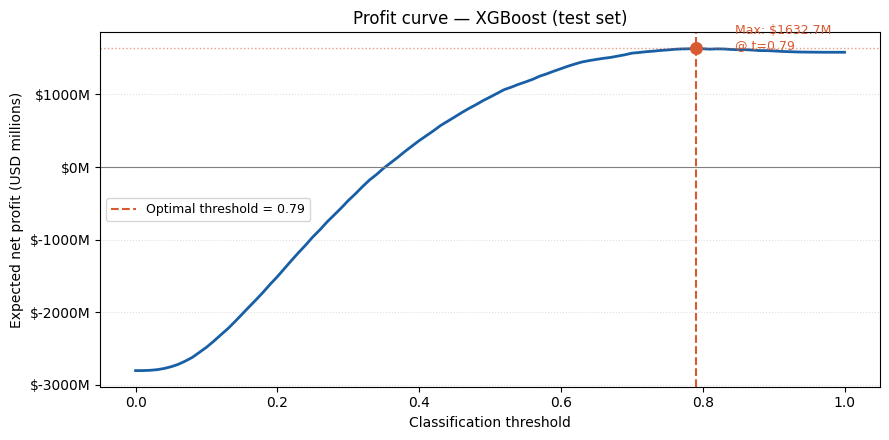

Profit curve saved.


In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# -----------------------------------------------------------------------------
# B.2  Profit curve — sweep threshold 0.00 → 1.00 in steps of 0.01
# -----------------------------------------------------------------------------
sweep = np.arange(0.00, 1.01, 0.01)
profits = [compute_financials(y_test, y_prob_test, amt_credit_test, t)["total_profit"]
           for t in sweep]

best_idx      = int(np.argmax(profits))
best_threshold = sweep[best_idx]
best_profit    = profits[best_idx]

print(f"\nB.2  Optimal threshold : {best_threshold:.2f}")
print(f"     Optimal net profit: ${best_profit:,.0f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sweep, [p / 1e6 for p in profits], color="#185FA5", linewidth=2)
ax.axvline(best_threshold, color="#D85A30", linestyle="--", linewidth=1.5,
           label=f"Optimal threshold = {best_threshold:.2f}")
ax.axhline(best_profit / 1e6, color="#D85A30", linestyle=":", linewidth=1,
           alpha=0.6)
ax.scatter([best_threshold], [best_profit / 1e6], color="#D85A30", zorder=5, s=70)
ax.annotate(f" Max: ${best_profit/1e6:.1f}M\n @ t={best_threshold:.2f}",
            xy=(best_threshold, best_profit / 1e6),
            xytext=(best_threshold + 0.05, best_profit / 1e6 - 5),
            fontsize=9, color="#D85A30")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="-")
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Expected net profit (USD millions)")
ax.set_title("Profit curve — XGBoost (test set)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.savefig("../data/curated/profit_curve.png", dpi=150)
plt.show()
print("Profit curve saved.")

#### 3. Compare the model’s expected profit against two baselines computed on the same test set: 
(a) approve everyone
(b) a random classifier with the same approval rate. Report the improvement in dollar terms and as a percentage.

In [15]:
# -----------------------------------------------------------------------------
# B.3  Compare against baselines (approve all / random classifier)
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("B.3  BASELINE COMPARISON  (test set, optimal threshold)")
print("="*70)

# --- Model at optimal threshold ---
model_result = compute_financials(y_test, y_prob_test, amt_credit_test, best_threshold)

# --- Baseline A: approve everyone ---
def approve_all(y_true, amt_credit):
    # every applicant is approved; predicted default = 0 for all
    TN = (y_true == 0).sum()
    FN = (y_true == 1).sum()
    profit  =  PROFIT_RATE  * amt_credit[y_true.values == 0].sum()
    loss    = -LOSS_RATE    * amt_credit[y_true.values == 1].sum()
    total   = profit + loss
    return {"name": "Approve all", "profit": total,
            "TN": int(TN), "FN": int(FN), "TP": 0, "FP": 0}

# --- Baseline B: random classifier with same approval rate as the model ---
approval_rate = model_result["approved"] / len(y_test)

np.random.seed(42)
rand_approved = np.random.binomial(1, approval_rate, size=len(y_test))  # 1 = approve
# treat approved=1 ↔ y_pred=0 in our convention
rand_pred = 1 - rand_approved

def random_baseline(y_true, amt_credit, rand_pred, label):
    TN = ((rand_pred == 0) & (y_true.values == 0)).sum()
    FN = ((rand_pred == 0) & (y_true.values == 1)).sum()
    FP = ((rand_pred == 1) & (y_true.values == 0)).sum()
    amt_TN = amt_credit[(rand_pred == 0) & (y_true.values == 0)]
    amt_FP = amt_credit[(rand_pred == 1) & (y_true.values == 0)]
    amt_FN = amt_credit[(rand_pred == 0) & (y_true.values == 1)]
    profit  =  PROFIT_RATE   * amt_TN.sum()
    loss    = -LOSS_RATE     * amt_FN.sum()
    opp     = -OPP_COST_RATE * amt_FP.sum()
    return {"name": label, "profit": profit + loss + opp,
            "TN": int(TN), "FN": int(FN), "FP": int(FP)}

all_result  = approve_all(y_test, amt_credit_test)
rand_result = random_baseline(y_test, amt_credit_test, rand_pred, "Random classifier")

results = [
    {"Strategy"    : "Approve all",
     "Net profit"  : all_result["profit"],
     "vs model ($)": model_result["total_profit"] - all_result["profit"],
     "vs model (%)" : (model_result["total_profit"] - all_result["profit"]) / abs(all_result["profit"]) * 100},
    {"Strategy"    : f"Random (approval rate={approval_rate:.1%})",
     "Net profit"  : rand_result["profit"],
     "vs model ($)": model_result["total_profit"] - rand_result["profit"],
     "vs model (%)" : (model_result["total_profit"] - rand_result["profit"]) / abs(rand_result["profit"]) * 100},
    {"Strategy"    : f"XGBoost (t={best_threshold:.2f})",
     "Net profit"  : model_result["total_profit"],
     "vs model ($)": 0,
     "vs model (%)" : 0.0},
]

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))
for r in results:
    print(f"\n  {r['Strategy']}: ${r['Net profit']:,.0f}")


B.3  BASELINE COMPARISON  (test set, optimal threshold)
                    Strategy   Net profit  vs model ($)  vs model (%)
                 Approve all 1.580242e+09    52443055.8      3.318672
Random (approval rate=95.6%) 1.384693e+09   247992459.3     17.909565
            XGBoost (t=0.79) 1.632685e+09           0.0      0.000000

  Approve all: $1,580,242,243

  Random (approval rate=95.6%): $1,384,692,840

  XGBoost (t=0.79): $1,632,685,299


#### 4. Consider our assumption that 50% of the loan amount is lost upon default. How sensitive are our conclusions to this assumption? Run experiments as needed.


B.4  SENSITIVITY ANALYSIS: loss rate on default
Loss rate  Optimal threshold  Model net profit ($M)  Approve-all profit ($M)  Improvement ($M)
      30%               0.89                2077.23                  2069.57              7.65
      35%               0.86                1960.97                  1947.24             13.72
      40%               0.83                1846.86                  1824.91             21.95
      45%               0.82                1736.08                  1702.58             33.51
      50%               0.79                1632.69                  1580.24             52.44
      55%               0.79                1529.55                  1457.91             71.65
      60%               0.77                1426.64                  1335.58             91.06
      65%               0.76                1328.22                  1213.24            114.97
      70%               0.76                1230.73                  1090.91            139.82
 

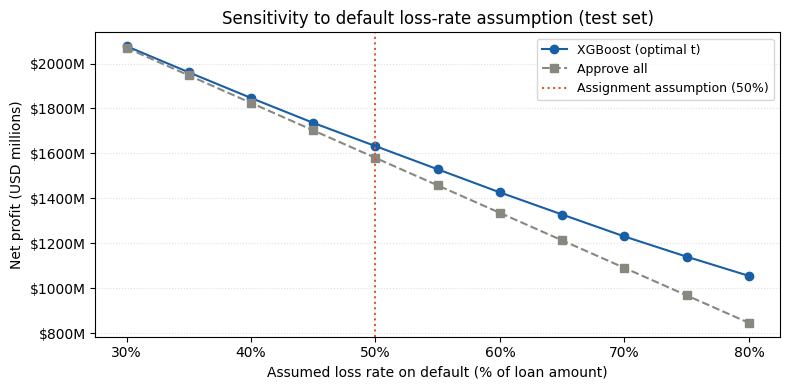

Sensitivity plot saved.

Section B complete.


In [16]:
# -----------------------------------------------------------------------------
# B.4  Sensitivity analysis — vary loss-on-default rate (30 % to 80 %)
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("B.4  SENSITIVITY ANALYSIS: loss rate on default")
print("="*70)

loss_rates = np.arange(0.30, 0.85, 0.05)
sens_rows  = []

for lr in loss_rates:
    def _profit_custom_loss(y_true, y_prob, amt, threshold, loss_r):
        y_pred   = (y_prob >= threshold).astype(int)
        amt_TN = amt[(y_pred == 0) & (y_true.values == 0)]
        amt_FP = amt[(y_pred == 1) & (y_true.values == 0)]
        amt_FN = amt[(y_pred == 0) & (y_true.values == 1)]
        return (PROFIT_RATE * amt_TN.sum()
                - loss_r    * amt_FN.sum()
                - OPP_COST_RATE * amt_FP.sum())

    # recalculate optimal threshold under this loss assumption
    ps_sweep = [_profit_custom_loss(y_test, y_prob_test, amt_credit_test, t, lr)
                for t in sweep]
    opt_t = sweep[int(np.argmax(ps_sweep))]
    opt_p = max(ps_sweep)

    # baseline approve-all under this loss
    base_p = (PROFIT_RATE * amt_credit_test[y_test.values == 0].sum()
              - lr         * amt_credit_test[y_test.values == 1].sum())

    sens_rows.append({
        "Loss rate": f"{lr:.0%}",
        "Optimal threshold": round(opt_t, 2),
        "Model net profit ($M)": round(opt_p / 1e6, 2),
        "Approve-all profit ($M)": round(base_p / 1e6, 2),
        "Improvement ($M)": round((opt_p - base_p) / 1e6, 2),
    })

sens_df = pd.DataFrame(sens_rows)
print(sens_df.to_string(index=False))

# Plot sensitivity
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_rates, [r["Model net profit ($M)"] for r in sens_rows],
        marker="o", label="XGBoost (optimal t)", color="#185FA5")
ax.plot(loss_rates, [r["Approve-all profit ($M)"] for r in sens_rows],
        marker="s", linestyle="--", label="Approve all", color="#888780")
ax.axvline(0.50, color="#D85A30", linestyle=":", linewidth=1.5,
           label="Assignment assumption (50%)")
ax.set_xlabel("Assumed loss rate on default (% of loan amount)")
ax.set_ylabel("Net profit (USD millions)")
ax.set_title("Sensitivity to default loss-rate assumption (test set)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.savefig("../data/curated/sensitivity_loss_rate.png", dpi=150)
plt.show()
print("Sensitivity plot saved.")

print("\nSection B complete.")
